# TiRex-2 Synthetic Multivariate Coupling

[TiRex-2](https://arxiv.org/abs/2607.01204) (Podest et al., 2026) pre-trains a multivariate time-series foundation model on **synthetically coupled** samples.
Curated multivariate corpora are too narrow to cover the dependency types a foundation model must handle, while **large univariate corpora are abundant**.
The coupling pipeline therefore draws a batch of univariate series from a shared pool and **composes them on the fly** into a multivariate example with a known cross-variate structure.

<p align="center">
<img width="80%" align="middle" src="../../docs/source/_static/TiRex-2.jpg">
</p>

## Why couple univariate series?

Real multivariate series mix several qualitatively distinct sources of dependence:

- shared latent drivers (factor-style mixing);
- lagged directed influence (causal lead–lag);
- deterministic functional covariates (sensor redundancies, calendar features);
- common stochastic trends (cointegration);
- observational artefacts (asynchronous sampling, dropouts, discretisation).

The pipeline is a **procedural prior**: each stage is randomised independently per example, so the training distribution is combinatorially larger than any fixed scenario list.

Reference: Podest, P., et al. (2026). *TiRex-2: Generalizing TiRex to Multivariate Data and Streaming*. arXiv:2607.01204, Section 3.4 and Appendix E–F.


## Algorithm (three stages)

At each draw the generator samples $V \sim U\{1,\ldots,12\}$ univariate series $z_1,\ldots,z_Q \in \mathbb{R}^{T}$ (here $Q = V$), then:

1. **Univariate pool + Stage-1 augmentation.**  
   Each series is independently perturbed with piecewise-linear amplitude trends, quantile censoring, and synthetic spikes, then cropped / NaN-padded to length $T$.  
   In this reproduction the default pool is a **zero-mean Gaussian process** whose kernel is randomly composed from a fixed bank under $\{+, \times\}$ (Appendix E, synthetic GP component).

2. **Coupling mechanism.**  
   Sample $m \sim \mathrm{Uniform}(\mathcal{M})$ with
   $$\mathcal{M} = \{\texttt{identity},\;\texttt{univariate},\;\texttt{functional},\;\texttt{linear mixing},\;\texttt{cointegration},\;\texttt{linear SCM},\;\texttt{nonlinear SCM}\}.$$
   Except for identity / univariate pass-through, $m$ maps the augmented series into jointly dependent variates $x_1,\ldots,x_Q$.

3. **Observational post-processing.**  
   Variate permutation, Brownian-bridge time warping, contiguous patch masking, partial future observability, and value / time discretisation.

**Output shape in this implementation:** $(T, Q)$ — $T$ time steps, $Q$ variates.  
Visualisation helpers (`plot_multivariate_time_series`, `plot_correlation`) expect $(Q, T)$, so plots below use `.T`.

**Adjacency convention:** `adjacency[i, j] = 1` means a directed edge **i → j**.


In [1]:
%matplotlib inline
import os
import sys

import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(os.path.join("..", "..")))

from s2generator.scm import CouplingPipeline
from s2generator.utils import (
    plot_univariate_time_series,
    plot_multivariate_time_series,
    plot_adjacency_matrix,
    plot_graph,
    plot_correlation,
    multivariate_correlation,
)


def channels(series: np.ndarray) -> np.ndarray:
    """Convert pipeline output (T, Q) to visualisation layout (Q, T)."""
    return np.asarray(series).T


def mean_offdiag_pearson(series_tq: np.ndarray) -> float:
    corr = multivariate_correlation(channels(series_tq), measure="pearson")
    q = corr.shape[0]
    mask = ~np.eye(q, dtype=bool)
    return float(np.mean(np.abs(corr[mask])))


T, Q = 256, 4
rng = np.random.RandomState(0)
pipe = CouplingPipeline()
print(pipe)
print("mechanisms:", list(pipe.mechanisms.keys()))

CouplingPipeline
mechanisms: ['identity', 'univariate', 'functional', 'linear_mixing', 'cointegration', 'linear_scm', 'nonlinear_scm']


## 1. Generate a coupled series from scratch

`generate` builds the GP univariate pool, applies Stage-1 augmentation, samples a coupling mechanism, and (by default) post-processes the result.
Post-processing is disabled in this cell so the series stay finite and the correlation matrix is well-defined.


shape (T, Q): (256, 4)
mechanism: linear_mixing
augmented: True | post_processed: False
mean |Pearson| off-diagonal: 0.656


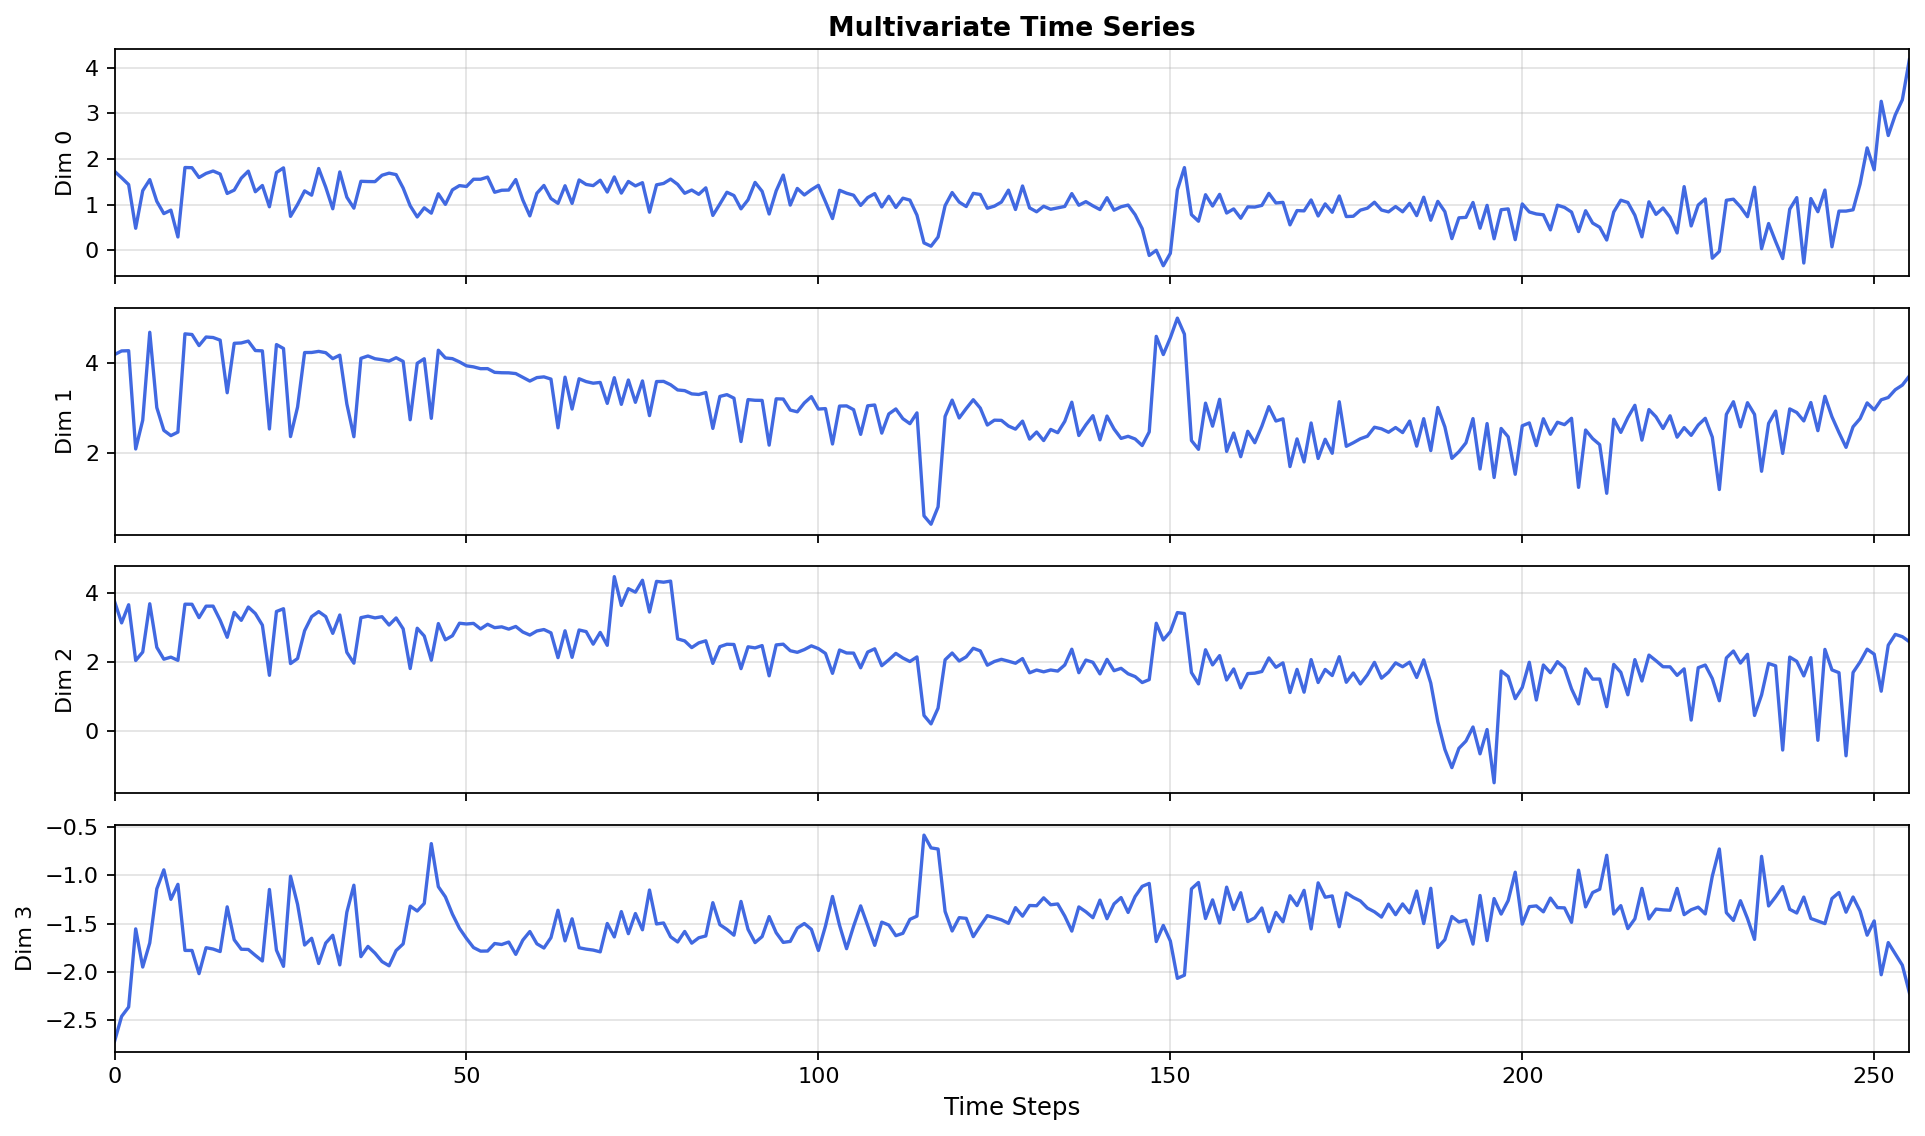

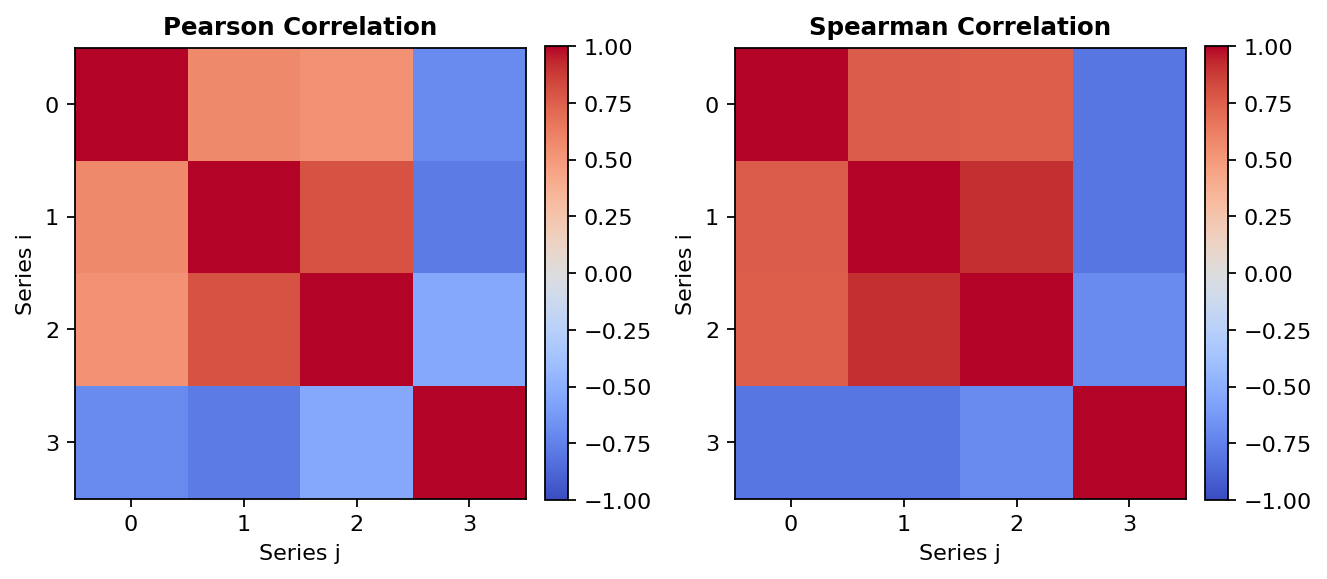

In [2]:
x, meta = pipe.generate(
    rng,
    n_inputs_points=T,
    input_dimension=Q,
    apply_postprocessing=False,
    return_metadata=True,
)
print("shape (T, Q):", x.shape)
print("mechanism:", meta["coupling_mechanism"])
print("augmented:", meta["augmented"], "| post_processed:", meta["post_processed"])
print("mean |Pearson| off-diagonal:", f"{mean_offdiag_pearson(x):.3f}")

fig = plot_multivariate_time_series(channels(x))
fig = plot_correlation(channels(x), measure="pearson spearman")
plt.show()

## 2. The seven coupling mechanisms

Each mechanism targets a different region of cross-variate dependency space (Section 3.4).
The next cells **fix** the mechanism, keep $T=256$, $Q=4$, and skip post-processing so the induced correlation is attributable to coupling alone.

| Name | Class | Uses input $z$? | Intended phenomenon |
| --- | --- | --- | --- |
| `identity` | `IdentityCoupling` | yes, $x_j = z_j$ | no-coupling control |
| `univariate` | `UnivariatePassThrough` | first column only | univariate pass-through |
| `functional` | `FunctionalCoupling` | $z_0$ only | deterministic covariates |
| `linear_mixing` | `LinearMixing` | all columns | shared latent drivers |
| `cointegration` | `Cointegration` | **no** (shape only) | common stochastic trends |
| `linear_scm` | `LinearSCM` | lagged parents | directed lead–lag |
| `nonlinear_scm` | `NonlinearSCM` | lagged parents + gate | state-dependent coupling |


### 2.1 Identity / pass-through

$$
x_{j,t} = z_{j,t}
$$

Each output variate is exactly the corresponding input. This is the **no-coupling control**: without it, a model trained only on coupled data would assume cross-variate structure even when none is present.


identity shape: (256, 4) | mean |rho|: 0.137


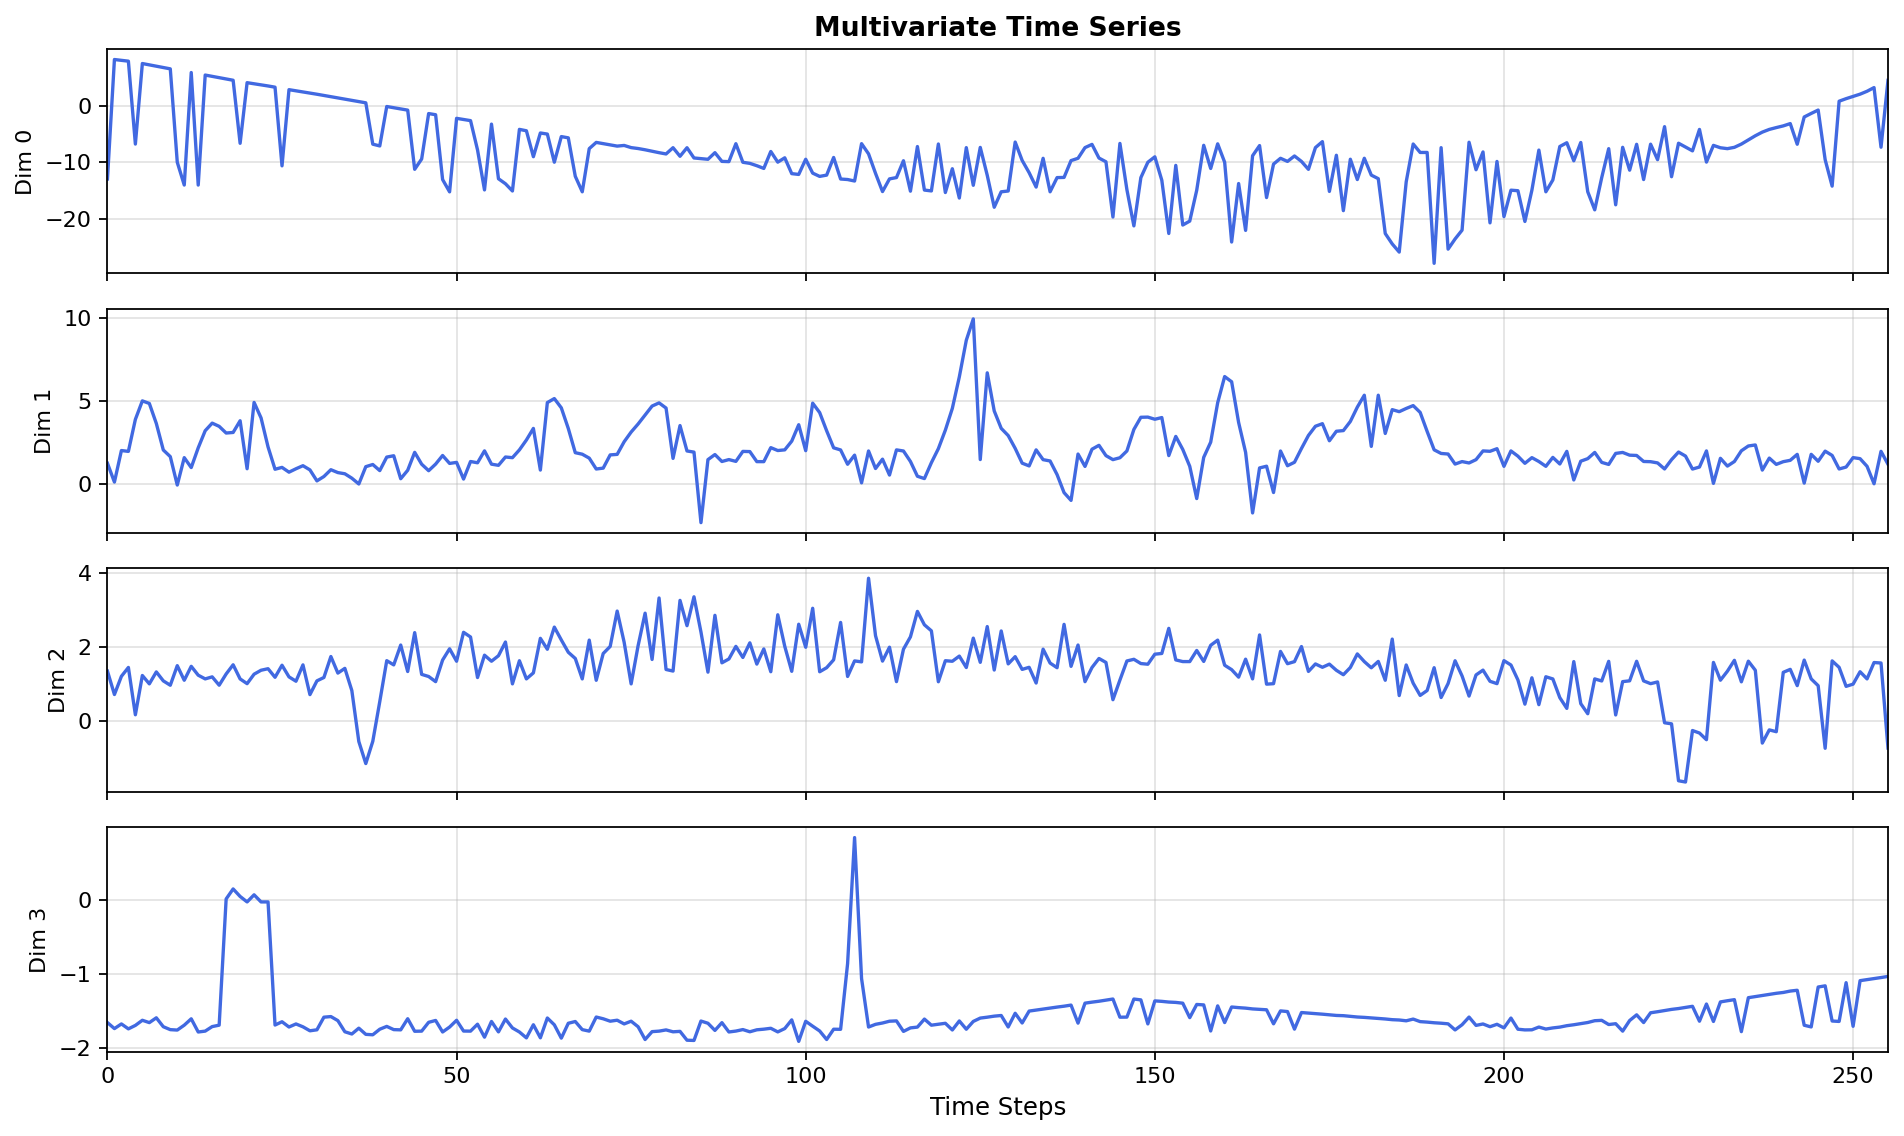

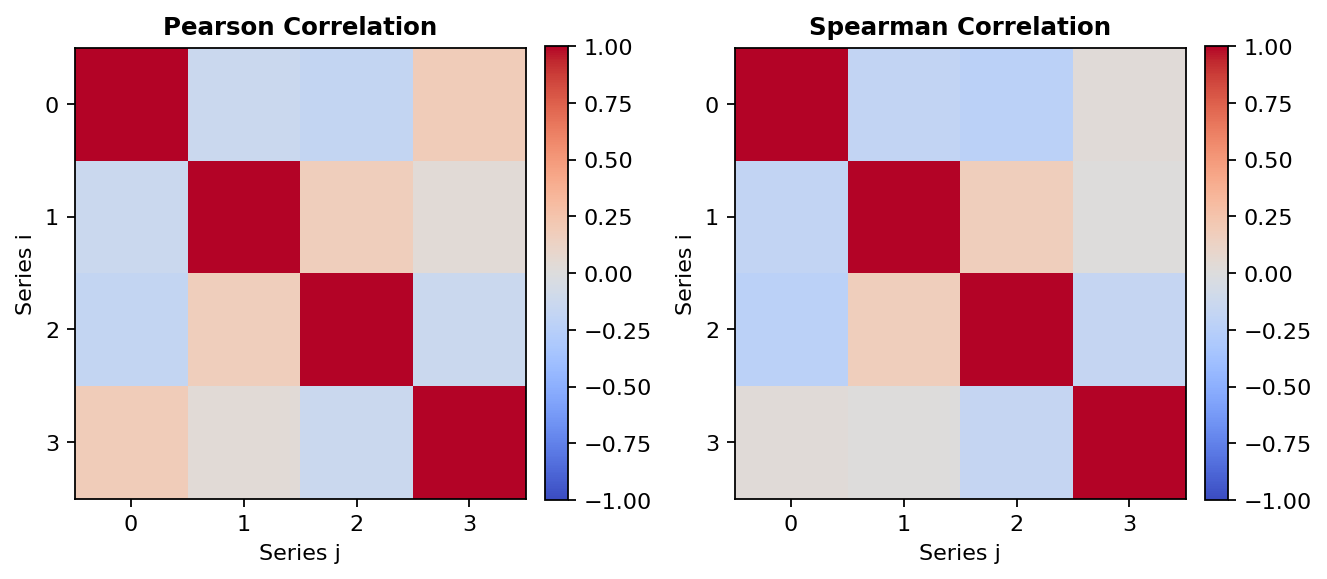

In [3]:
rng = np.random.RandomState(1)
x = pipe.generate(
    rng, T, input_dimension=Q, mechanism="identity", apply_postprocessing=False
)
print("identity shape:", x.shape, "| mean |rho|:", f"{mean_offdiag_pearson(x):.3f}")
fig = plot_multivariate_time_series(channels(x))
fig = plot_correlation(channels(x), measure="pearson spearman")
plt.show()

### 2.2 Univariate pass-through

A single univariate output $x_t = z_{0,t}$. The remaining $Q-1$ inputs are discarded and the array becomes $(T, 1)$.
This preserves the univariate forecasting regime in which the variate mixer is bypassed.


univariate shape: (256, 1)


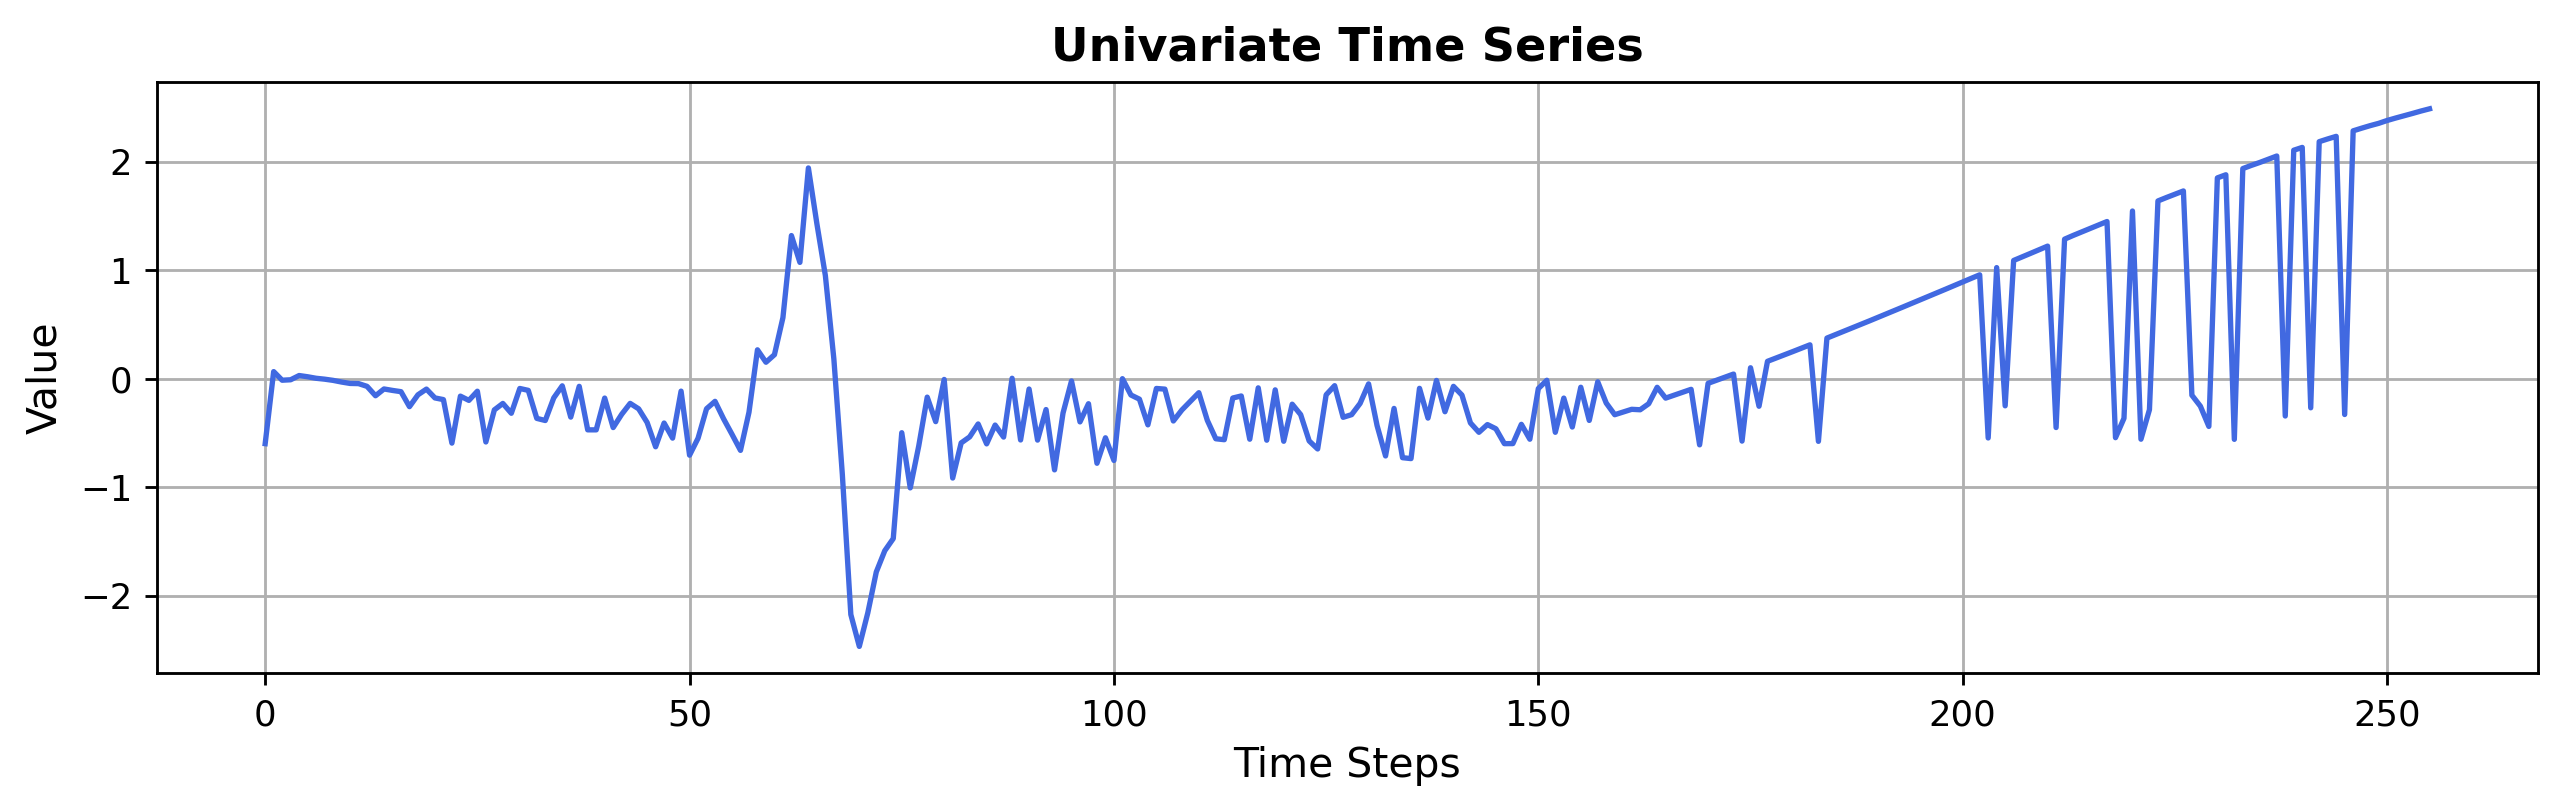

In [4]:
rng = np.random.RandomState(2)
x = pipe.generate(
    rng, T, input_dimension=Q, mechanism="univariate", apply_postprocessing=False
)
print("univariate shape:", x.shape)
fig = plot_univariate_time_series(x[:, 0])
plt.show()

### 2.3 Functional coupling

$$
x_{0,t} = z_{0,t},\qquad
x_{j,t} = f_j(z_{0,t}) + \varepsilon_{j,t}\quad (j \ge 1)
$$

$f_j$ is sampled from monotone, compressive, discretising, piecewise-linear, or polynomial maps.
This is the **direct pointwise** extreme: covariates are (near-)deterministic transformations of a shared base series, as in sensor redundancies or derived calendar features.
Because every channel is a function of $z_0$, Pearson correlation is typically large.


functional shape: (256, 4) | mean |rho|: 0.776


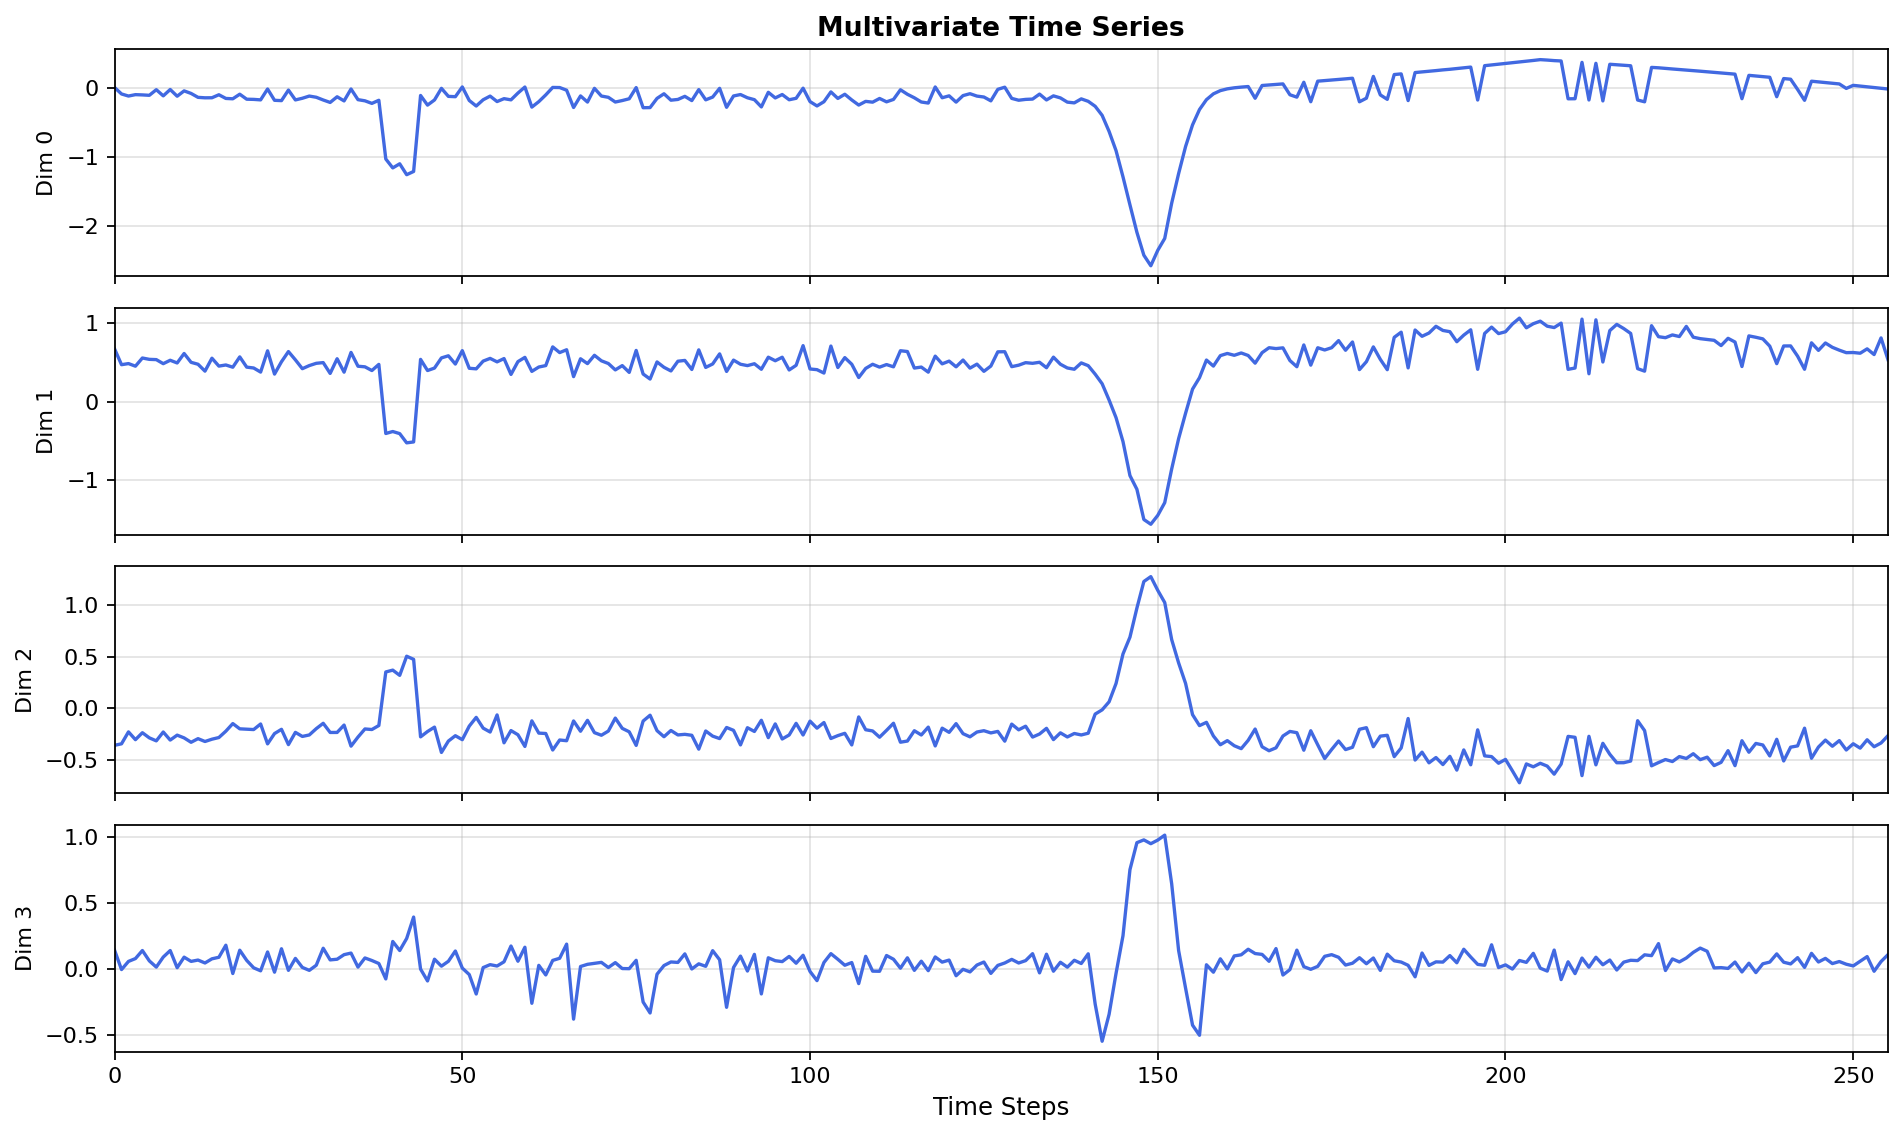

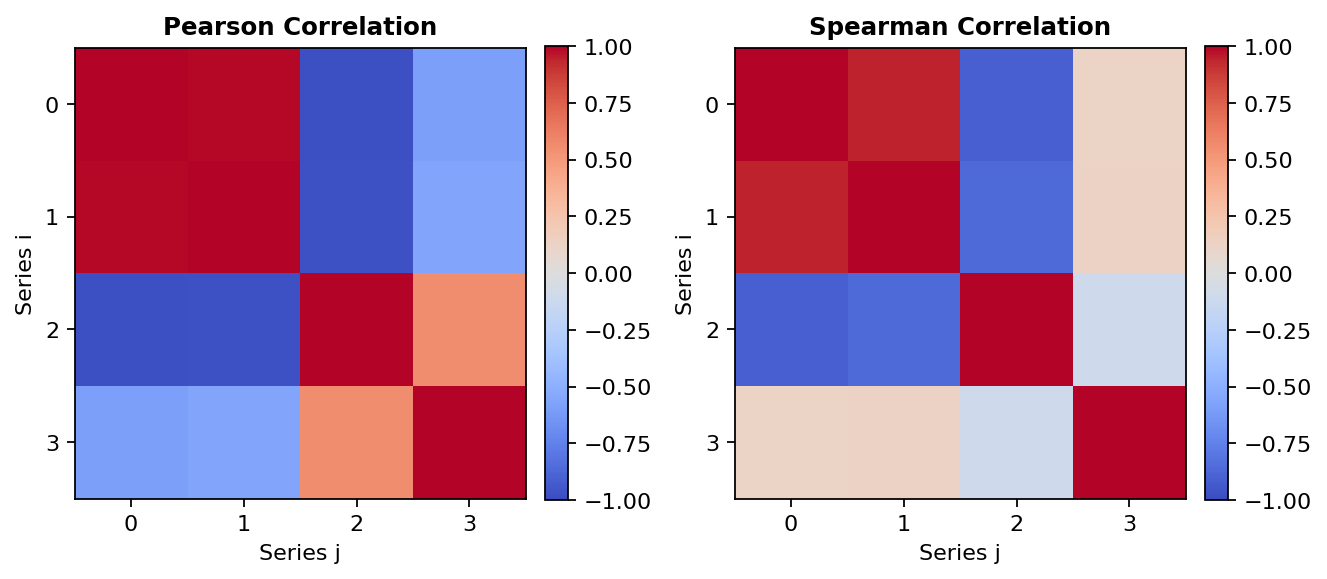

In [5]:
rng = np.random.RandomState(3)
x = pipe.generate(
    rng, T, input_dimension=Q, mechanism="functional", apply_postprocessing=False
)
print("functional shape:", x.shape, "| mean |rho|:", f"{mean_offdiag_pearson(x):.3f}")
fig = plot_multivariate_time_series(channels(x))
fig = plot_correlation(channels(x), measure="pearson spearman")
plt.show()

### 2.4 Linear mixing

$$
x(t) = A\, z(t)
$$

Observed series arise as linear combinations of the independent inputs. The singular-value spectrum of $A$ is sampled from **dominant**, **uniform**, or **power-law** regimes, so the induced correlation ranges from near-independence to near-collinearity (factor-model structure).


linear_mixing shape: (256, 4) | mean |rho|: 0.375


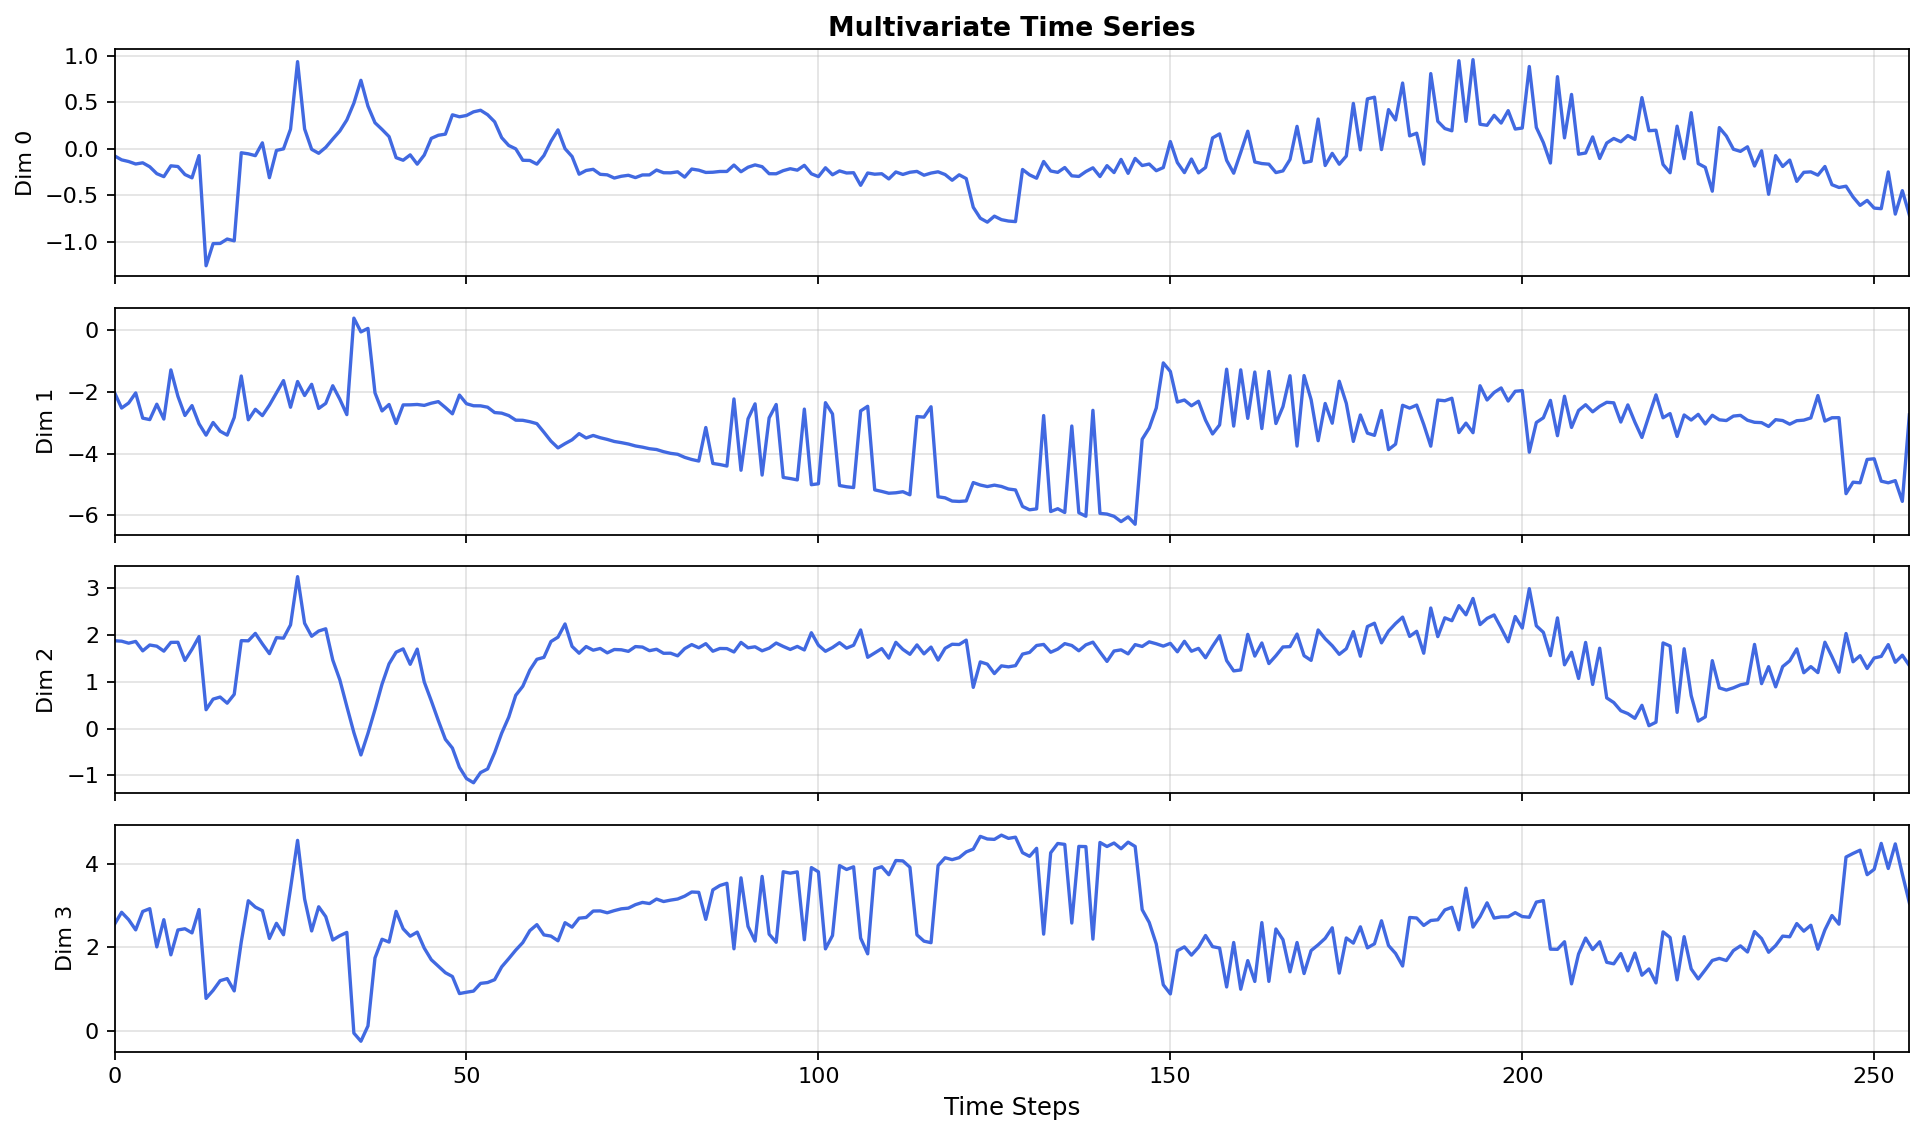

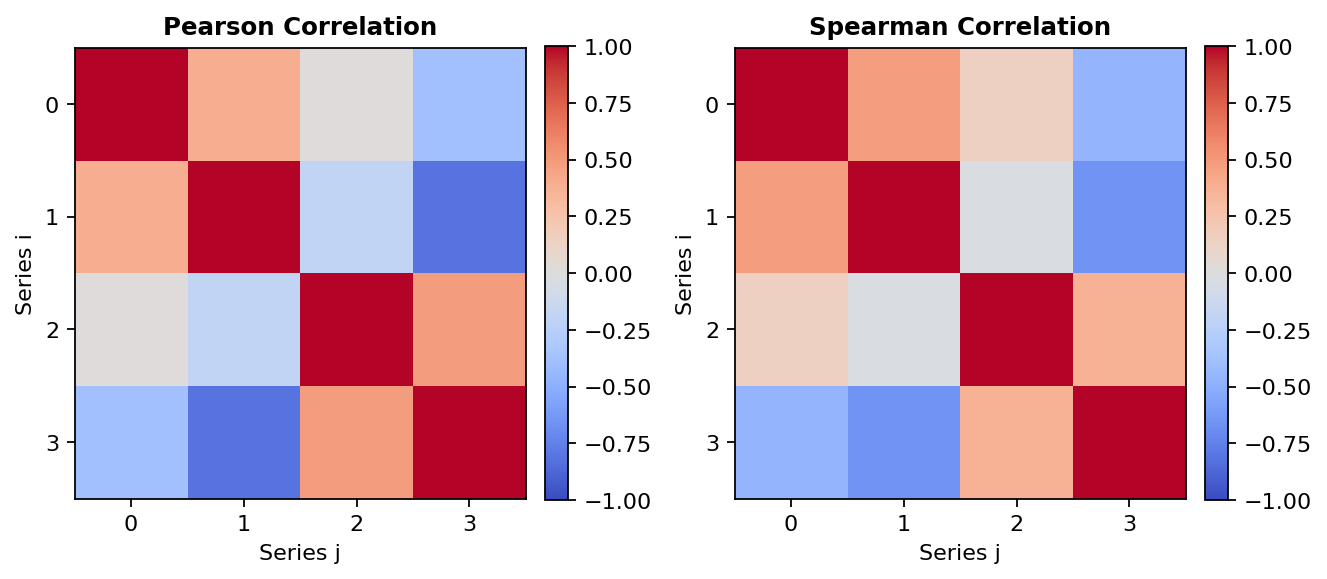

In [6]:
rng = np.random.RandomState(4)
x = pipe.generate(
    rng, T, input_dimension=Q, mechanism="linear_mixing", apply_postprocessing=False
)
print(
    "linear_mixing shape:", x.shape, "| mean |rho|:", f"{mean_offdiag_pearson(x):.3f}"
)
fig = plot_multivariate_time_series(channels(x))
fig = plot_correlation(channels(x), measure="pearson spearman")
plt.show()

### 2.5 Cointegration

$$
x(t) = \Lambda\, \tau(t) + \xi(t)
$$

Shared random-walk trends $\tau$ load onto the variates through $\Lambda$; $\xi$ are stationary AR(1) residuals.
Individual series may drift without bound while some linear combinations remain stationary.

**Implementation note.** This mechanism uses the input only for the shape $(T, Q)$. The trends and residuals are drawn from scratch, which matches the paper formula (the $z_j$ do not appear).


cointegration shape: (256, 4) | mean |rho|: 0.457


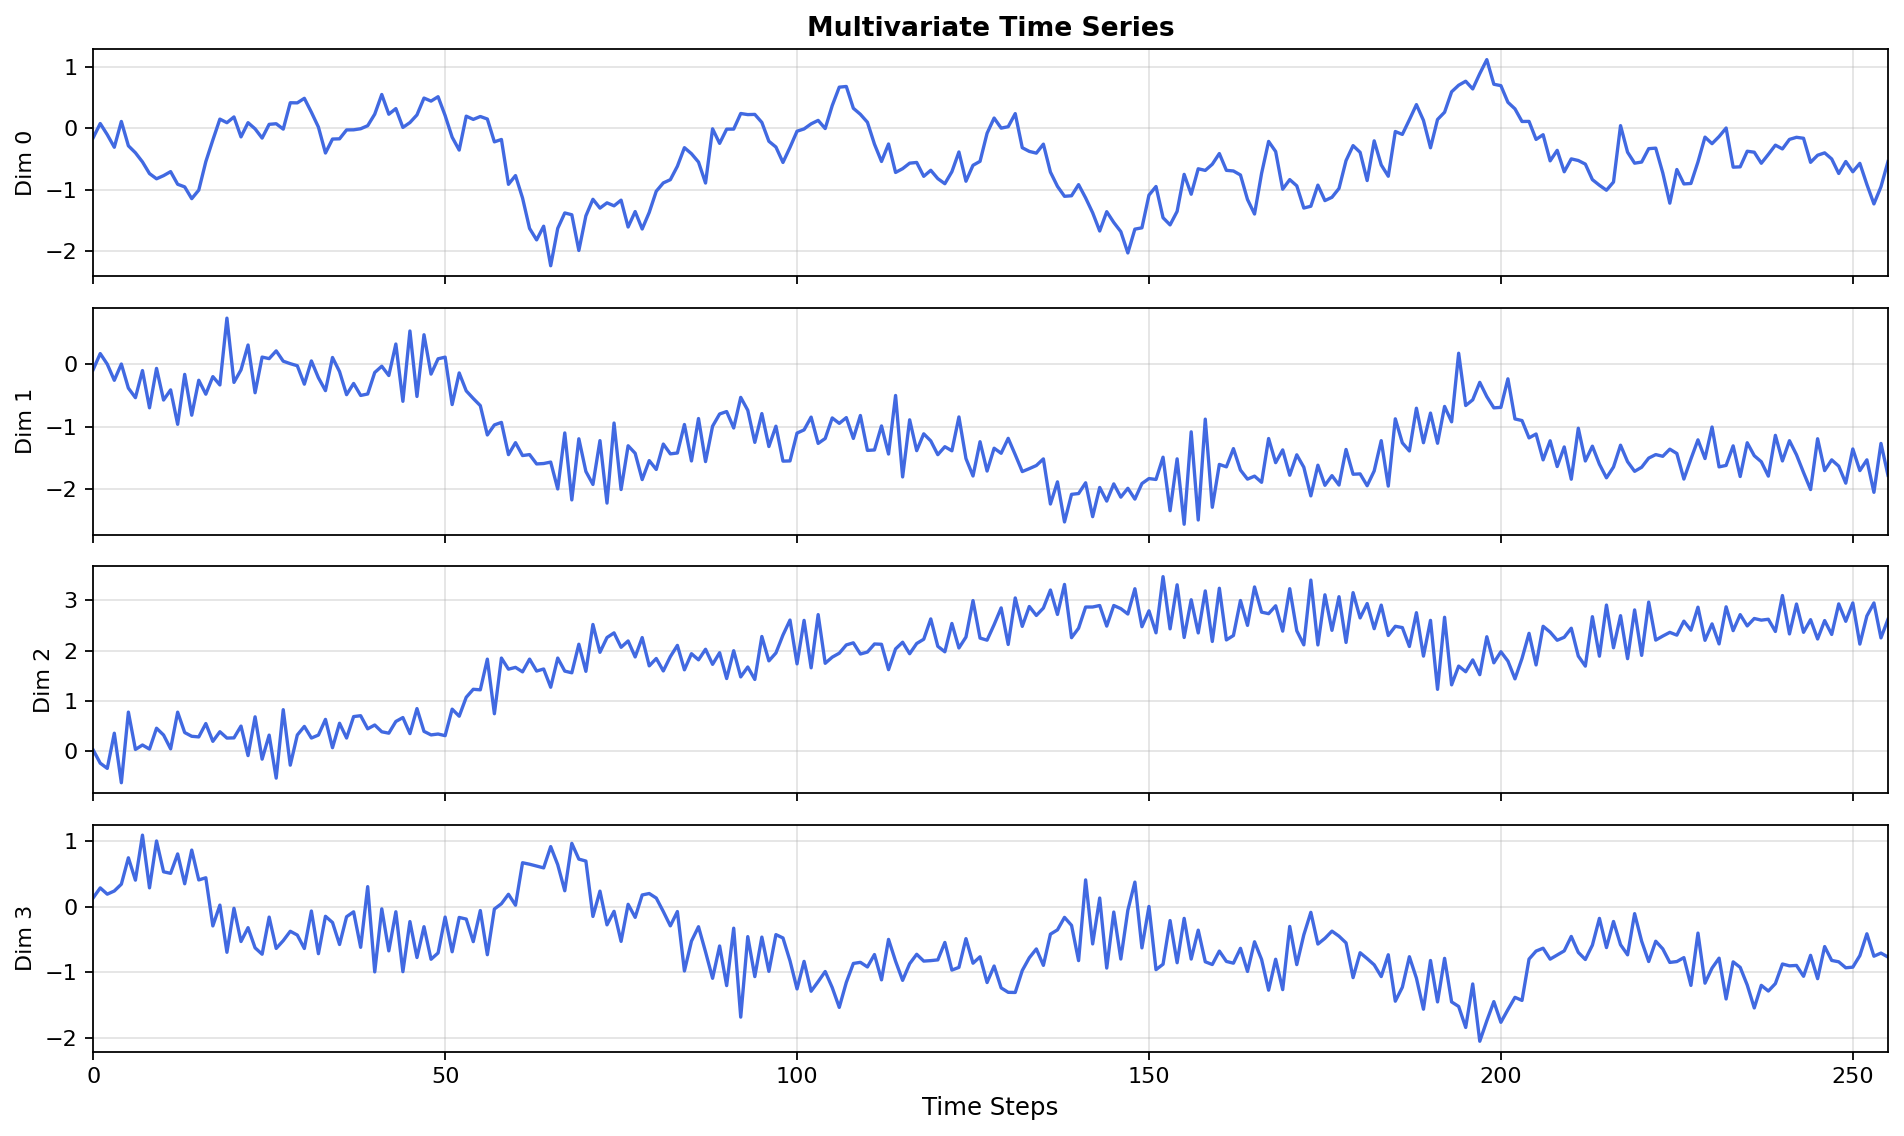

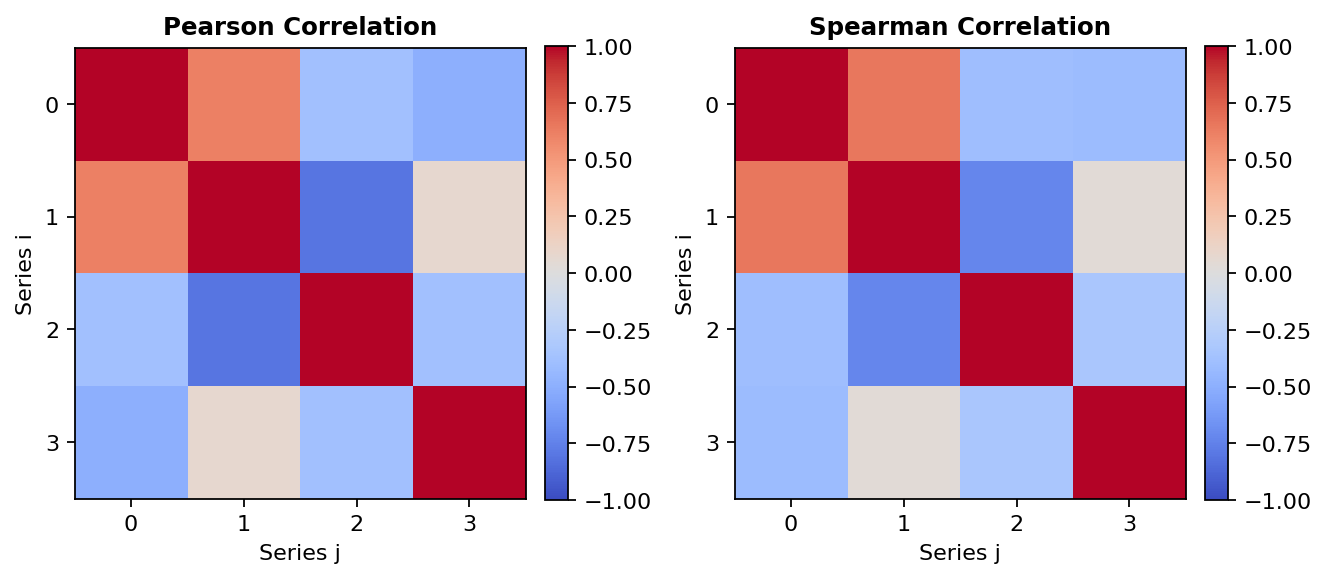

In [7]:
rng = np.random.RandomState(5)
x = pipe.generate(
    rng, T, input_dimension=Q, mechanism="cointegration", apply_postprocessing=False
)
print(
    "cointegration shape:", x.shape, "| mean |rho|:", f"{mean_offdiag_pearson(x):.3f}"
)
fig = plot_multivariate_time_series(channels(x))
fig = plot_correlation(channels(x), measure="pearson spearman")
plt.show()

### 2.6 Linear structural causal model

$$
x_{j,t} = \sum_{i \in \mathrm{pa}(j)} \alpha_{ij}\, z_{i,\, t-\tau_{ij}} + \varepsilon_{j,t}
$$

A random DAG over the $Q$ variates introduces **directed, lagged** dependence that instantaneous mixing cannot produce.
Root nodes (empty parent set) become noise; children mix lagged parent series.


linear_scm shape: (256, 4) | mean |rho|: 0.027


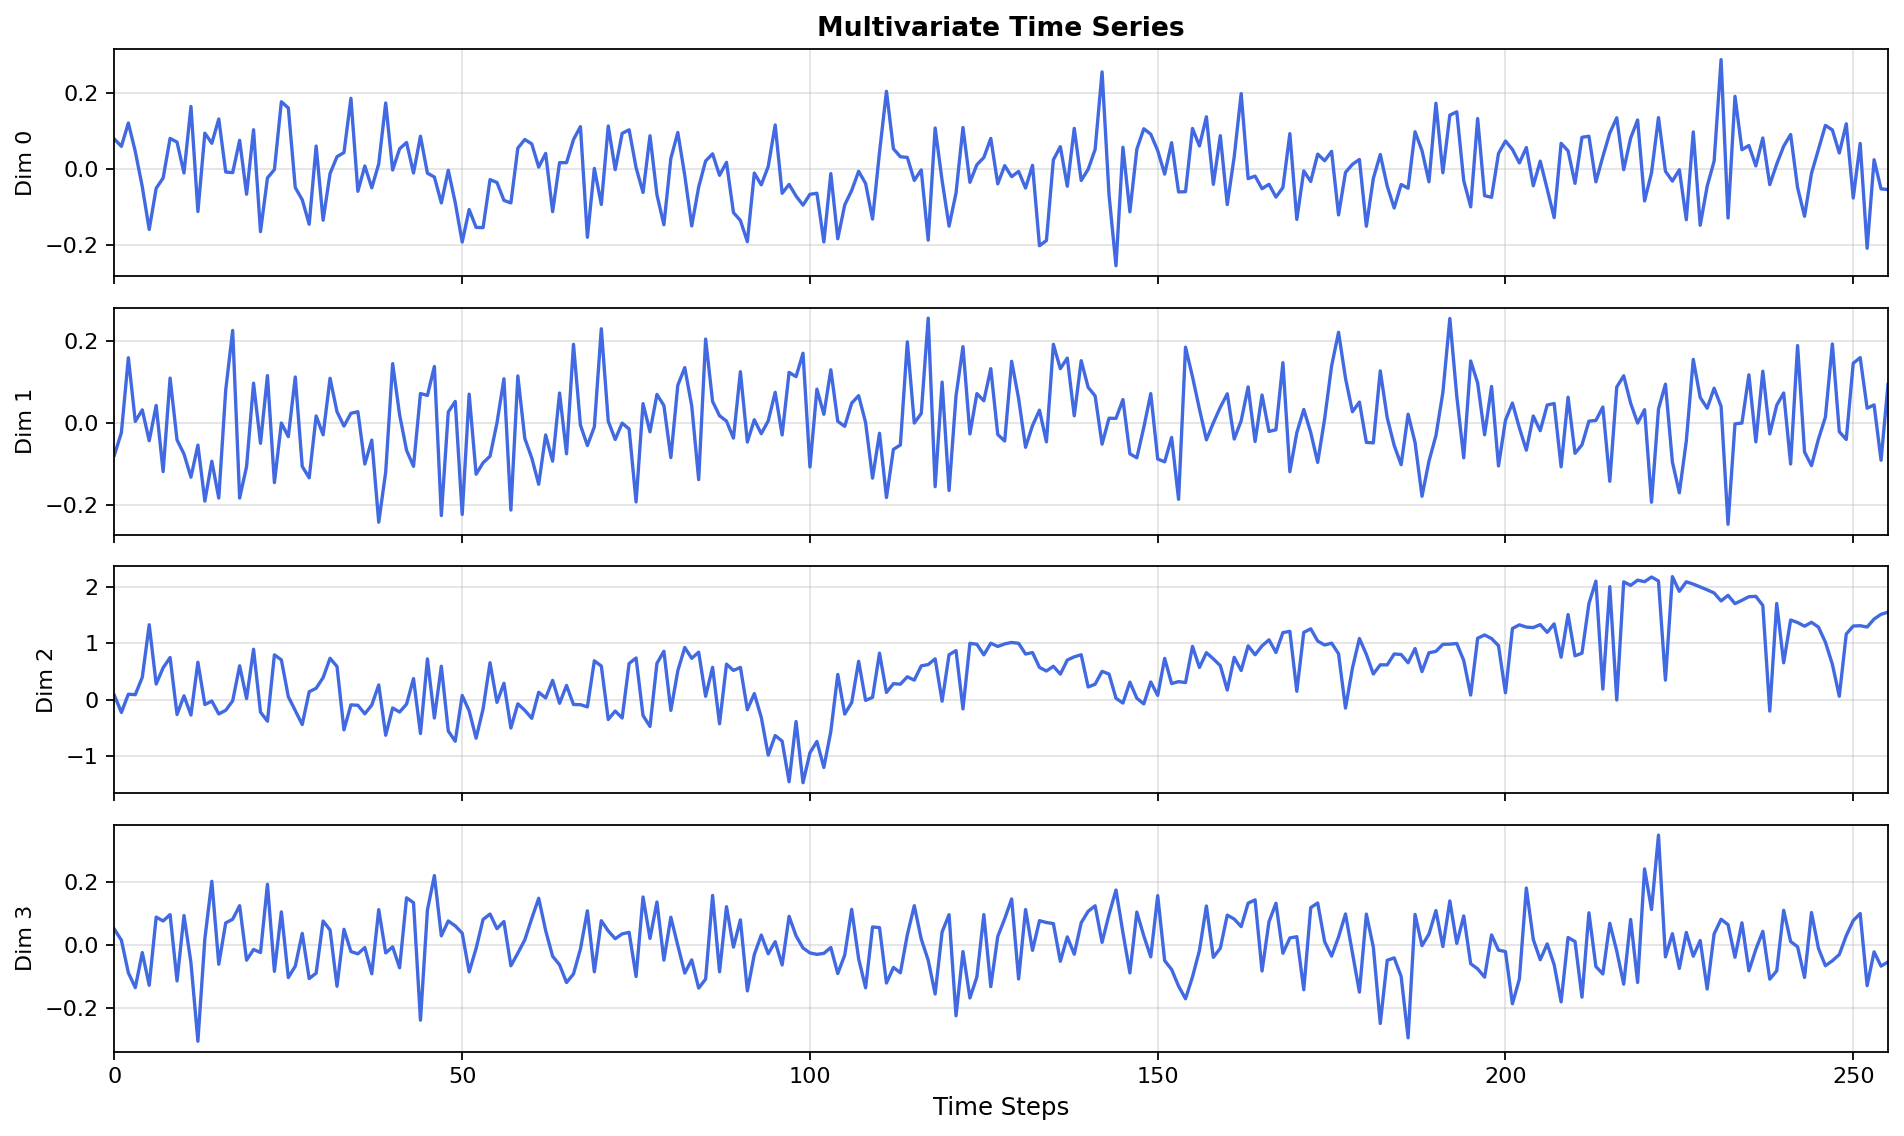

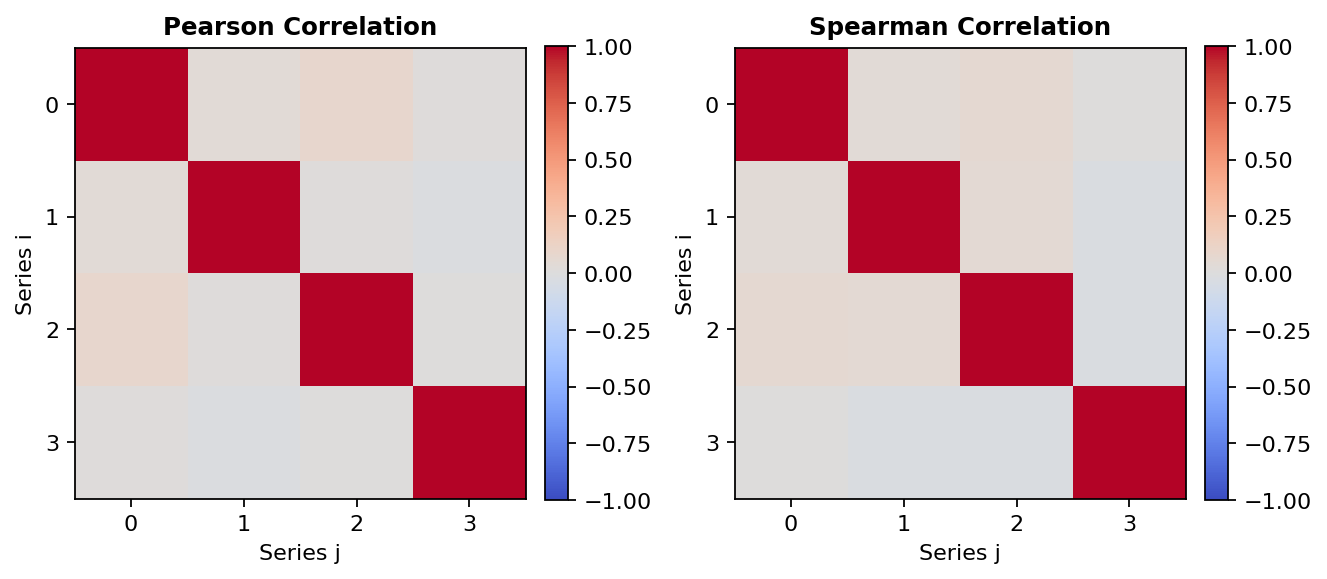

In [8]:
rng = np.random.RandomState(6)
x = pipe.generate(
    rng, T, input_dimension=Q, mechanism="linear_scm", apply_postprocessing=False
)
print("linear_scm shape:", x.shape, "| mean |rho|:", f"{mean_offdiag_pearson(x):.3f}")
fig = plot_multivariate_time_series(channels(x))
fig = plot_correlation(channels(x), measure="pearson spearman")
plt.show()

Custom DAG: a chain $0 \to 1 \to 2 \to 3$. The adjacency only fixes parent structure; lags and coefficients are still sampled per edge.


custom DAG shape: (256, 4) | custom_adjacency: True


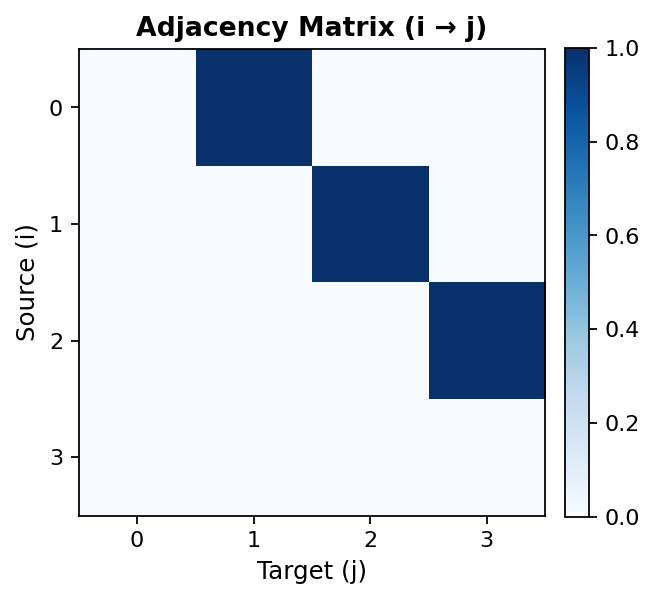

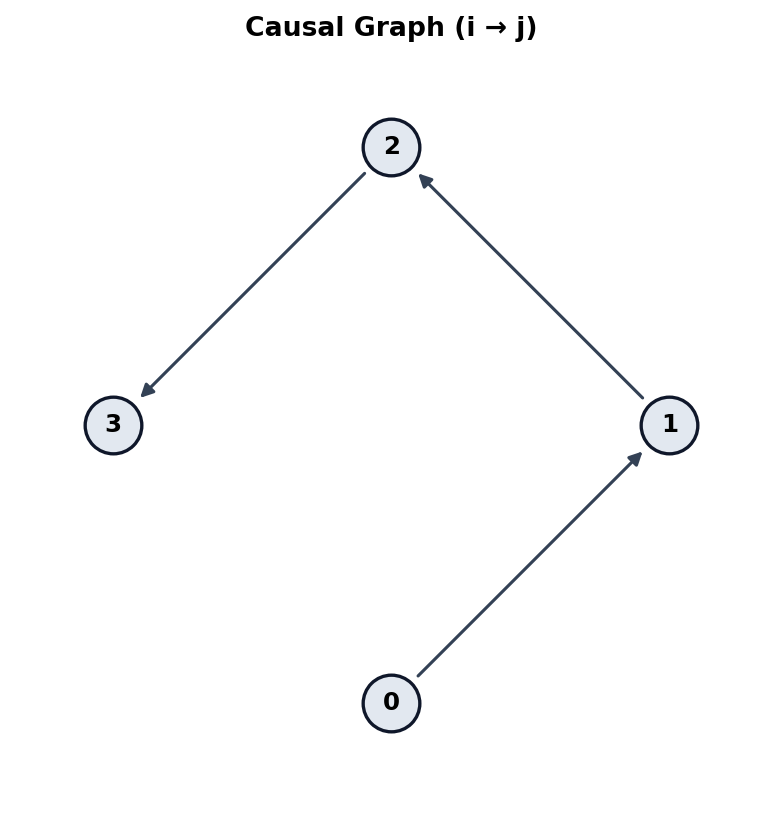

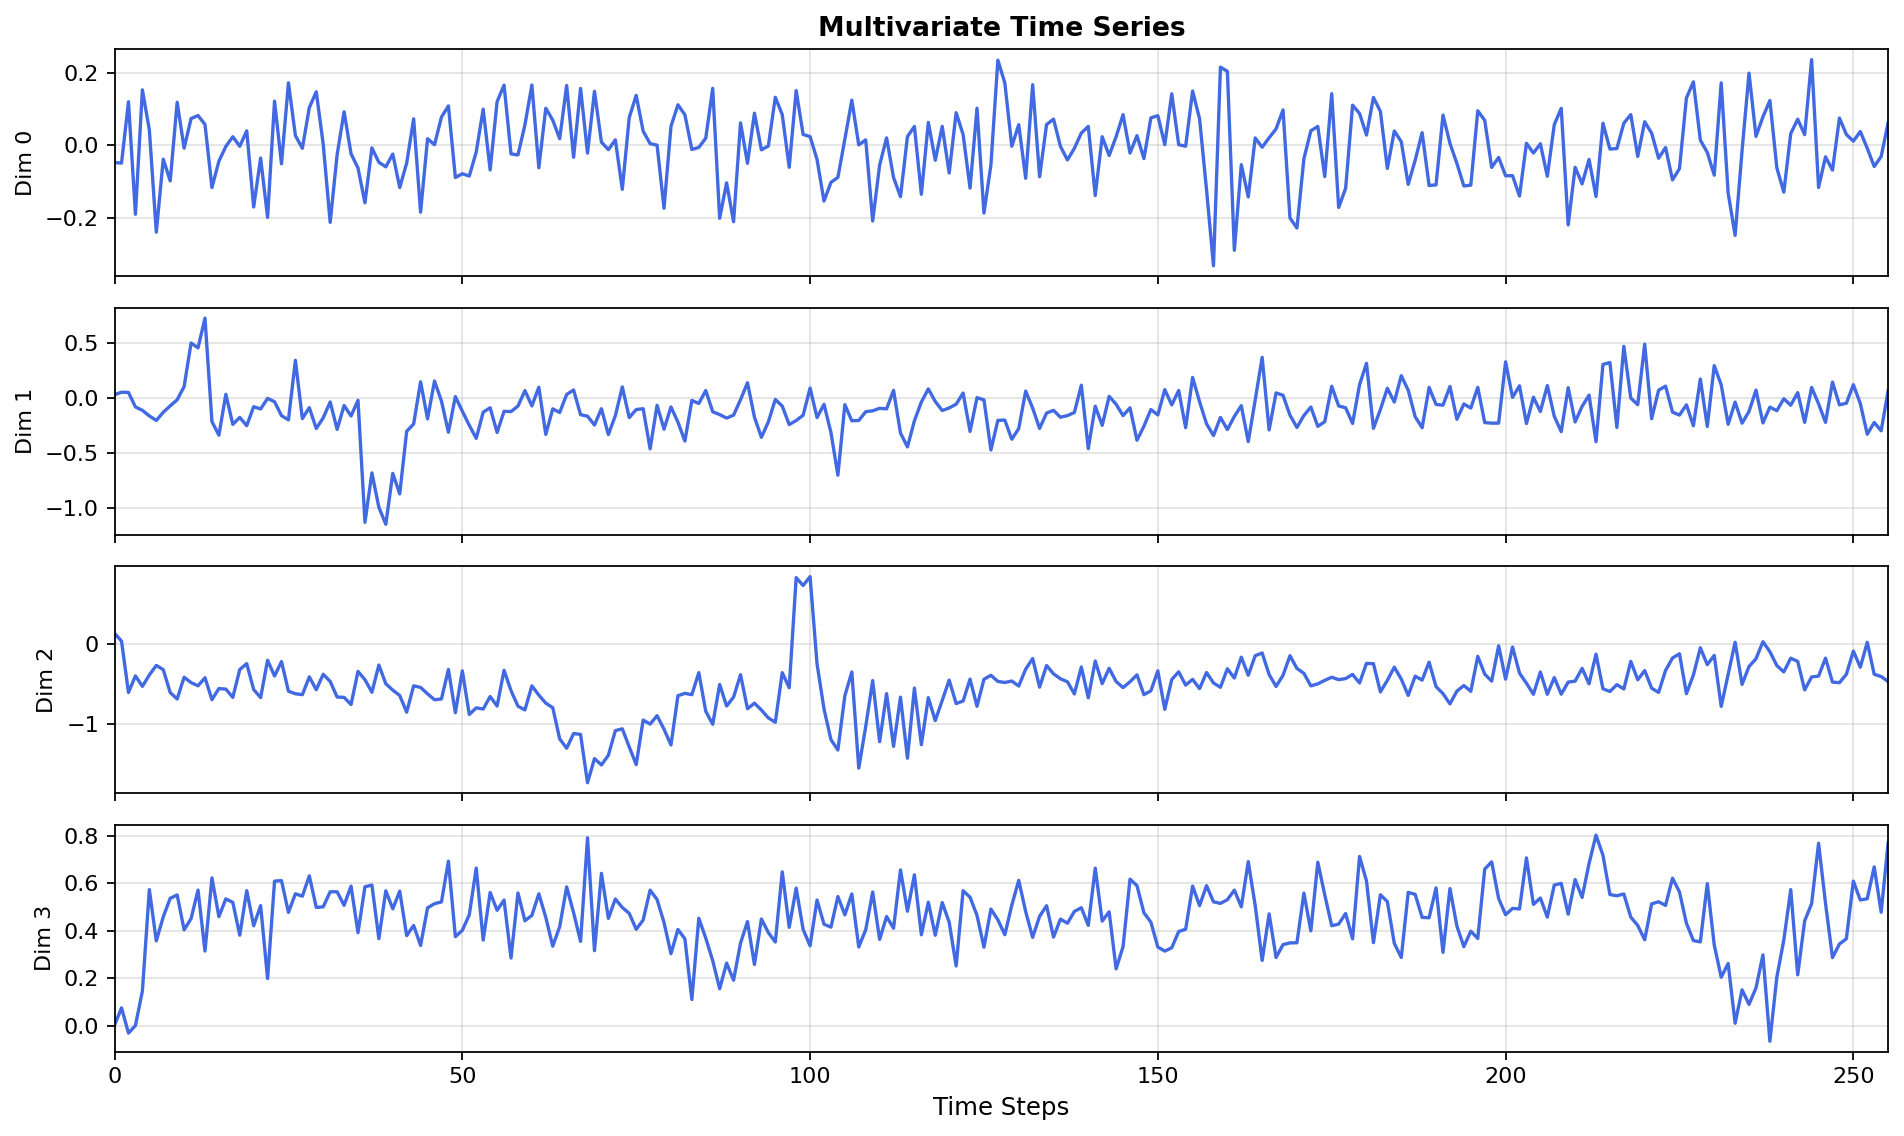

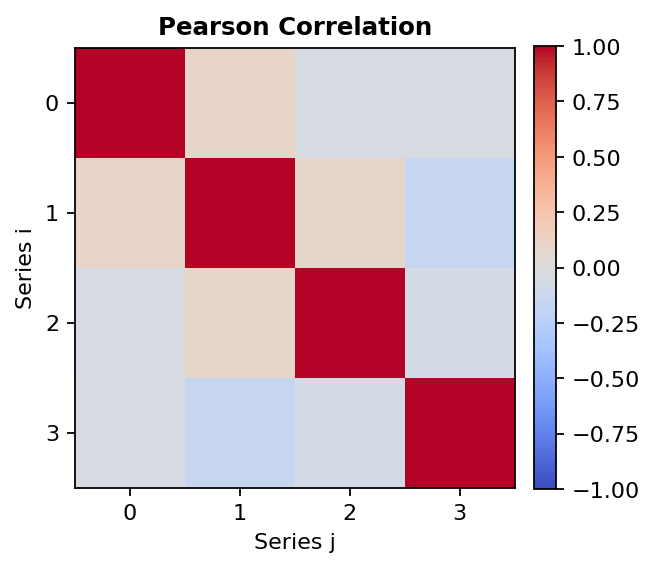

In [9]:
rng = np.random.RandomState(7)
adj = np.zeros((Q, Q), dtype=bool)
for i in range(Q - 1):
    adj[i, i + 1] = True

x, meta = pipe.generate(
    rng,
    T,
    mechanism="linear_scm",
    adjacency=adj,
    apply_postprocessing=False,
    return_metadata=True,
)
print("custom DAG shape:", x.shape, "| custom_adjacency:", meta["custom_adjacency"])
fig = plot_adjacency_matrix(adj.astype(int))
fig = plot_graph(adj.astype(int))
fig = plot_multivariate_time_series(channels(x))
fig = plot_correlation(channels(x), measure="pearson")
plt.show()

### 2.7 Nonlinear SCM with optional modulation gate

$$
x_{j,t} = h\!\left(z_{k,\, t-\tau_k}\right)
\sum_{i \in \mathrm{pa}(j)} g_{ij}\!\left(z_{i,\, t-\tau_{ij}}\right)
$$

Edge maps $g_{ij}$ are nonlinear (tanh, sigmoid, ReLU, sin, …). The optional multiplicative gate $h$ is a proxy for threshold-driven / regime-switching dynamics: one variate controls how strongly the others couple.


nonlinear_scm shape: (256, 4) | mean |rho|: 0.127


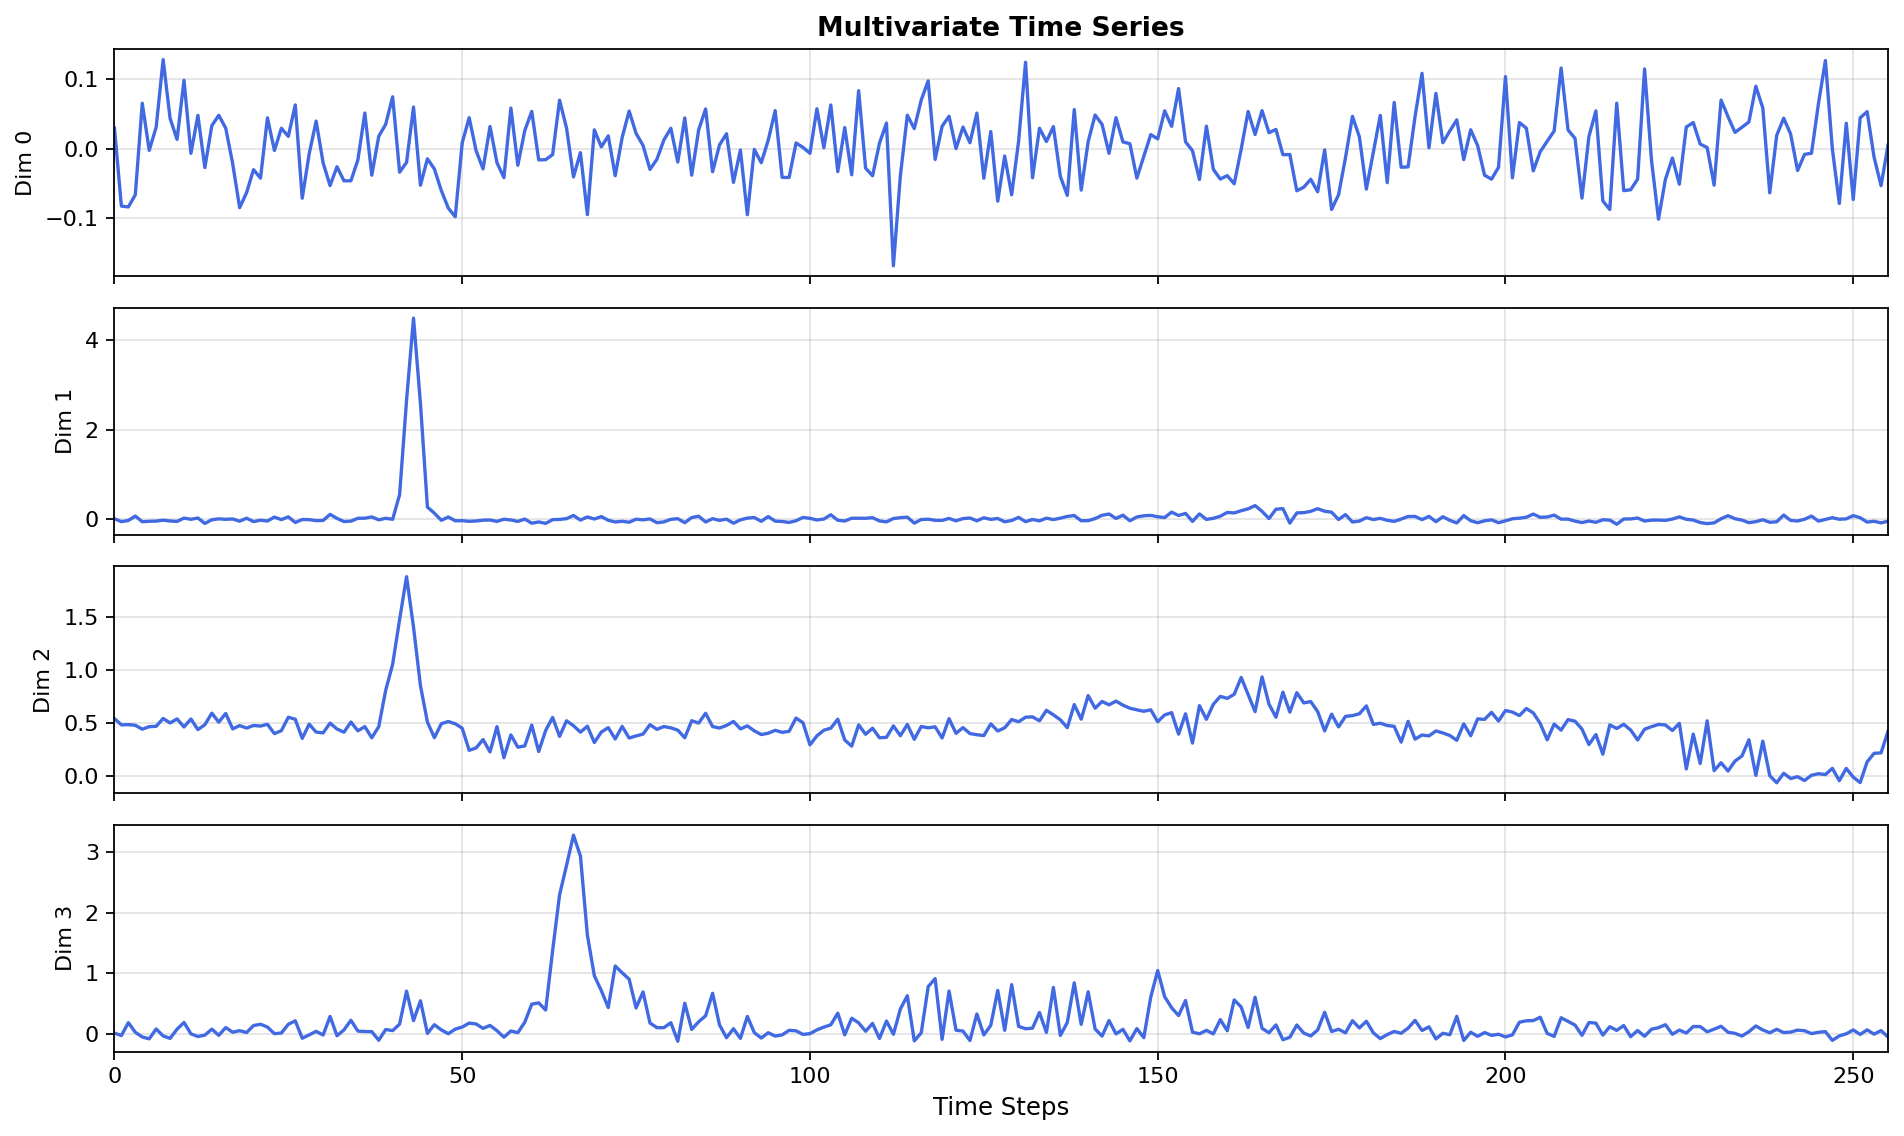

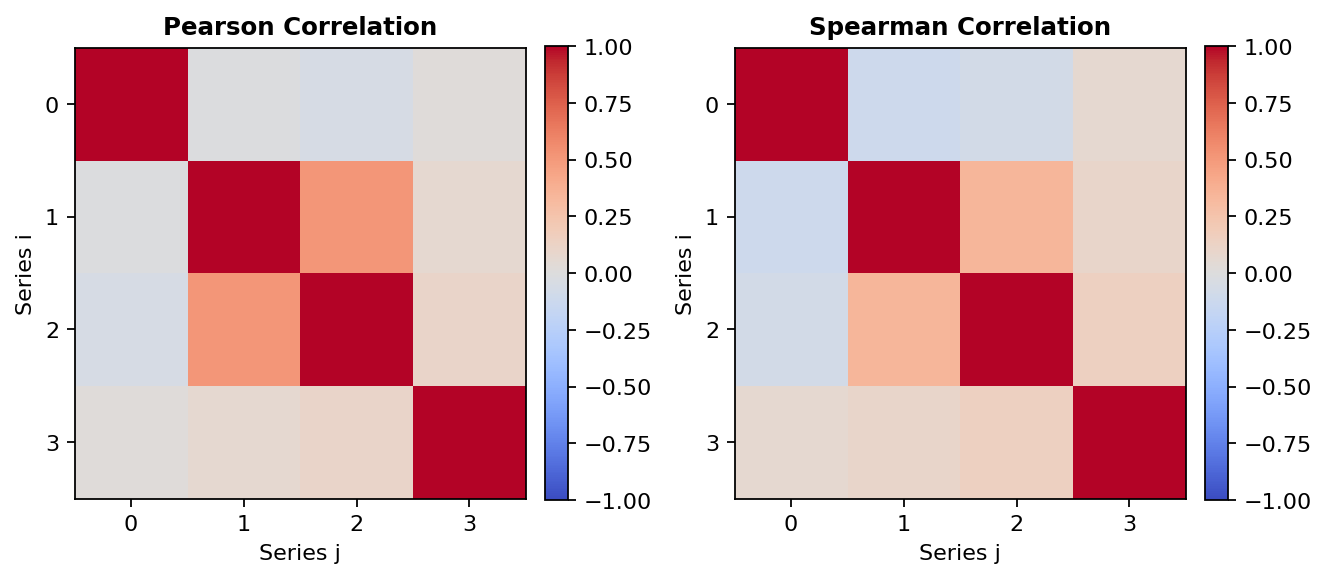

In [10]:
rng = np.random.RandomState(8)
x = pipe.generate(
    rng, T, input_dimension=Q, mechanism="nonlinear_scm", apply_postprocessing=False
)
print(
    "nonlinear_scm shape:", x.shape, "| mean |rho|:", f"{mean_offdiag_pearson(x):.3f}"
)
fig = plot_multivariate_time_series(channels(x))
fig = plot_correlation(channels(x), measure="pearson spearman")
plt.show()

## 3. Observational post-processing

Stage 3 superimposes artefacts that dominate the gap between a clean generative process and deployed data: channel reordering, asynchronous sampling, contiguous NaN dropouts, partial future covariates, and value / time discretisation.
Each transform is itself sampled with a per-example probability, so enabling `apply_postprocessing=True` may introduce NaNs.


post-processed shape: (256, 4)
NaN fraction: 0.2158203125


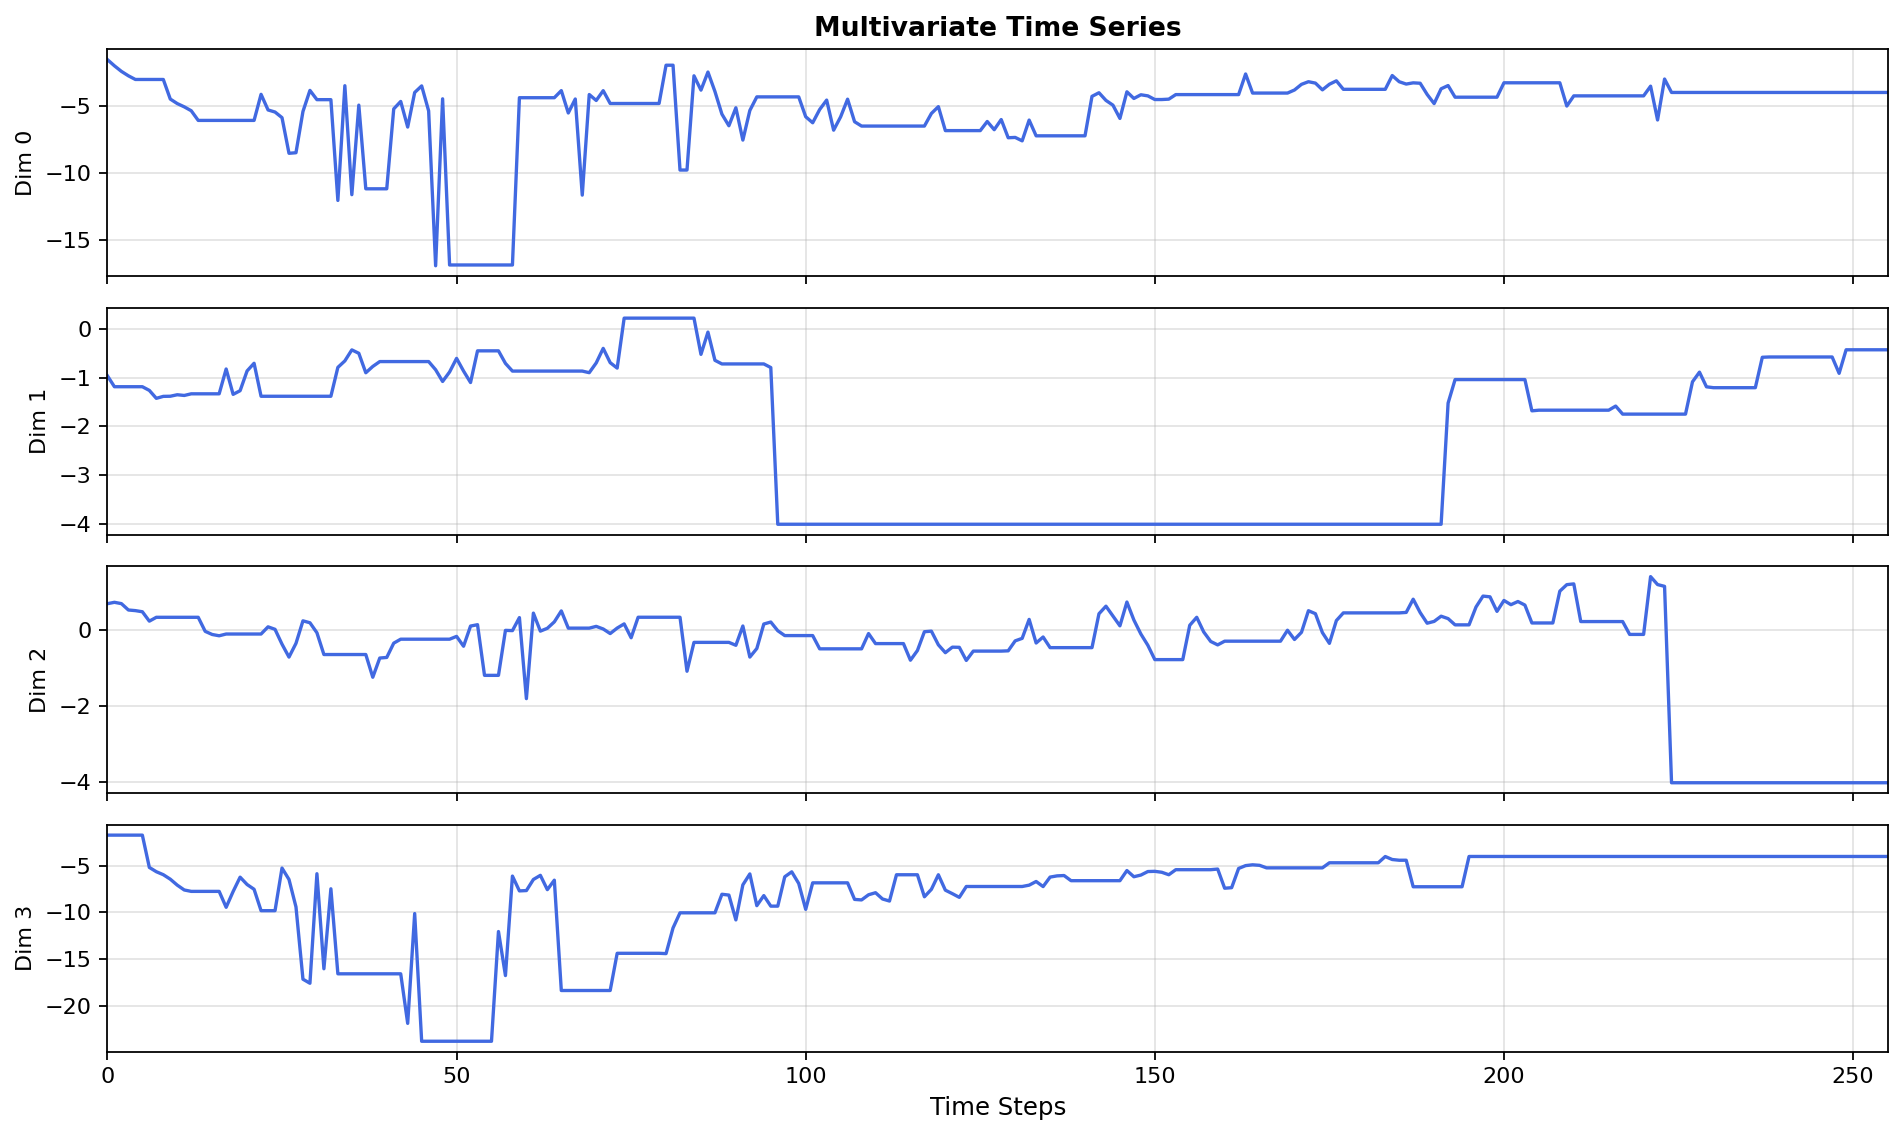

In [11]:
rng = np.random.RandomState(9)
x = pipe.generate(
    rng,
    T,
    input_dimension=Q,
    mechanism="linear_mixing",
    apply_postprocessing=True,
)
print("post-processed shape:", x.shape)
print("NaN fraction:", float(np.isnan(x).mean()))
finite = x.copy()
finite[np.isnan(finite)] = np.nanmean(x)
fig = plot_multivariate_time_series(channels(finite))
plt.show()

## Summary

| API | Role |
| --- | --- |
| `CouplingPipeline.generate` | From-scratch sample: GP pool → augment → couple → post-process |
| `CouplingPipeline.generate_batch` | Repeated `generate` (optional balanced labels via `n_classes`) |
| `CouplingPipeline.__call__` | Couple an **existing** `(T, Q)` array (see `coupling_real.ipynb`) |
| `plot_multivariate_time_series` / `plot_univariate_time_series` | Series visualisation (expects `(Q, T)` / `(L,)`) |
| `plot_correlation` / `multivariate_correlation` | Channel-wise dependence diagnostics |
| `plot_graph` / `plot_adjacency_matrix` | SCM parent structure |
